# investigate IP utilization of anycast prefixes

## questions
* how many IPs are used in anycast deployments?
* are there ASes with high utilization?
* are there ASes with low utilization (DNS?)
* are there ASes with a mix of high and low utilization
* which prefixes are HRP?
* which ASes deploy HRP?

In [1]:
import pandas as pd
from pathlib import Path

import sys
analysis_dir = Path.cwd().parent
sys.path.append(str(analysis_dir))
from add_ASN import CaidaASLookup
import census_helper
from datetime import datetime

ts = datetime(2026, 2, 4)

import matplotlib.pyplot as plt

# configure matplotlib variables (font and size)
plt.rcParams["axes.labelsize"] = 20
plt.rcParams.update({'font.size': 14})


/Users/remi/.venvs/default/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# load in census data

census_v4 = census_helper.download_date(ts, 'v4')
# filter on GCD-confirmed (high-confidence)
census_v4 = census_v4[census_v4['GCD_ICMPv4'] > 1]

census_v4

,prefix,AB_ICMPv4,AB_TCPv4,AB_DNSv4,GCD_ICMPv4,GCD_TCPv4,partial,backing_prefix,ASN,locations
0,1.0.0.0/24,29,29,27,77,15,False,1.0.0.0/24,13335,"[{'city': 'Bangalore', 'country_code': 'IN', '..."
1,1.1.1.0/24,29,29,27,74,13,False,1.1.1.0/24,13335,"[{'city': 'Bangalore', 'country_code': 'IN', '..."
3,1.10.10.0/24,3,0,3,3,0,False,1.10.10.0/24,148000,"[{'city': 'Mumbai', 'country_code': 'IN', 'id'..."
4,1.12.0.0/24,5,0,5,5,0,False,1.12.0.0/20,132203_45090,"[{'city': 'Hong Kong', 'country_code': 'HK', '..."
5,1.12.12.0/24,3,1,0,3,1,False,1.12.0.0/20,132203_45090,"[{'city': 'Hong Kong', 'country_code': 'HK', '..."
...,...,...,...,...,...,...,...,...,...,...
36387,99.83.254.0/24,27,0,0,58,0,False,99.83.240.0/20,16509,"[{'city': 'Bangkok', 'country_code': 'TH', 'id..."
36388,99.83.255.0/24,27,0,0,58,0,False,99.83.240.0/20,16509,"[{'city': 'Bangkok', 'country_code': 'TH', 'id..."
36394,99.99.97.0/24,2,1,1,2,1,False,99.96.0.0/13,7018,"[{'city': 'Dallas', 'country_code': 'US', 'id'..."
36395,99.99.98.0/24,2,0,2,2,0,False,99.96.0.0/13,7018,"[{'city': 'Atlanta', 'country_code': 'US', 'id..."


In [5]:
# load in HRP data

hrp = pd.read_csv('nl-ens_20260204_slash24-info.csv.gz')
hrp['/24'] = hrp['network_address'] + '/24'
hrp

,network_address,prefixlen,bgp_prefix,asn,responsive_addresses,port,date,location,/24
0,1.0.0.0,24,1.1.1.0/24,13335,256,80,20260204,nl-ens,1.0.0.0/24
1,1.1.1.0,24,1.10.10.0/24,148000,256,80,20260204,nl-ens,1.1.1.0/24
2,2.57.91.0,24,2.58.104.0/24,55532,256,80,20260204,nl-ens,2.57.91.0/24
3,2.58.104.0,24,2.58.107.0/24,55532,256,80,20260204,nl-ens,2.58.104.0/24
4,2.58.107.0,24,3.2.8.0/24,16509,256,80,20260204,nl-ens,2.58.107.0/24
...,...,...,...,...,...,...,...,...,...
9681,217.72.12.0,24,217.72.192.0/20,8560,256,80,20260204,nl-ens,217.72.12.0/24
9682,217.114.94.0,24,217.146.18.0/24,42388,256,80,20260204,nl-ens,217.114.94.0/24
9683,217.163.76.0,24,217.182.0.0/16,16276,256,80,20260204,nl-ens,217.163.76.0/24
9684,223.5.5.0,24,223.6.6.0/24,45102,256,80,20260204,nl-ens,223.5.5.0/24


In [6]:
# join census with HRP

census_v4['is_hrp'] = census_v4['prefix'].isin(hrp['/24'])

print(f"there are {census_v4['prefix'].nunique():,} /24s of which {census_v4[census_v4['is_hrp']]['prefix'].nunique():,} are HRP")

there are 14,331 /24s of which 9,686 are HRP


In [7]:
# load in IPs with services (excluding unknowns)

ip_services = pd.read_csv('nl-ens_ips-with-service_20260204_v4.csv.gz')
ip_services

,ip
0,1.0.0.132
1,1.1.1.109
2,1.1.1.125
3,1.1.1.250
4,1.1.1.83
...,...
1534290,34.54.211.100
1534291,51.68.117.37
1534292,66.225.252.253
1534293,85.128.164.161


In [8]:
ip_services['/24'] = (
    ip_services['ip']
        .str.split('.')
        .str[:3]
        .str.join('.') + '.0/24'
)

ip_services['/24'].nunique()

13189

In [32]:
ip_services['ip'].count()

np.int64(1534295)

In [9]:
# count number of active IPs per /24

ip_counts = (
    ip_services
        .groupby('/24')
        .size()
)

ip_counts

/24
1.0.0.0/24        256
1.1.1.0/24        256
1.10.10.0/24        2
1.12.0.0/24        40
1.12.12.0/24        1
                 ... 
99.83.254.0/24    116
99.83.255.0/24    105
99.99.97.0/24      20
99.99.98.0/24      20
99.99.99.0/24      12
Length: 13189, dtype: int64

In [10]:
census_v4['number_of_active_ips'] = (
    census_v4['prefix']
        .map(ip_counts)
        .fillna(0)
        .astype(int)
)

census_v4

,prefix,AB_ICMPv4,AB_TCPv4,AB_DNSv4,GCD_ICMPv4,GCD_TCPv4,partial,backing_prefix,ASN,locations,is_hrp,number_of_active_ips
0,1.0.0.0/24,29,29,27,77,15,False,1.0.0.0/24,13335,"[{'city': 'Bangalore', 'country_code': 'IN', '...",True,256
1,1.1.1.0/24,29,29,27,74,13,False,1.1.1.0/24,13335,"[{'city': 'Bangalore', 'country_code': 'IN', '...",True,256
3,1.10.10.0/24,3,0,3,3,0,False,1.10.10.0/24,148000,"[{'city': 'Mumbai', 'country_code': 'IN', 'id'...",False,2
4,1.12.0.0/24,5,0,5,5,0,False,1.12.0.0/20,132203_45090,"[{'city': 'Hong Kong', 'country_code': 'HK', '...",False,40
5,1.12.12.0/24,3,1,0,3,1,False,1.12.0.0/20,132203_45090,"[{'city': 'Hong Kong', 'country_code': 'HK', '...",False,1
...,...,...,...,...,...,...,...,...,...,...,...,...
36387,99.83.254.0/24,27,0,0,58,0,False,99.83.240.0/20,16509,"[{'city': 'Bangkok', 'country_code': 'TH', 'id...",False,116
36388,99.83.255.0/24,27,0,0,58,0,False,99.83.240.0/20,16509,"[{'city': 'Bangkok', 'country_code': 'TH', 'id...",False,105
36394,99.99.97.0/24,2,1,1,2,1,False,99.96.0.0/13,7018,"[{'city': 'Dallas', 'country_code': 'US', 'id'...",False,20
36395,99.99.98.0/24,2,0,2,2,0,False,99.96.0.0/13,7018,"[{'city': 'Atlanta', 'country_code': 'US', 'id...",False,20


In [11]:
# calculate IP utilization per /24

census_v4['ip_utilization'] = (
    census_v4['number_of_active_ips'] / 256
)

census_v4

,prefix,AB_ICMPv4,AB_TCPv4,AB_DNSv4,GCD_ICMPv4,GCD_TCPv4,partial,backing_prefix,ASN,locations,is_hrp,number_of_active_ips,ip_utilization
0,1.0.0.0/24,29,29,27,77,15,False,1.0.0.0/24,13335,"[{'city': 'Bangalore', 'country_code': 'IN', '...",True,256,1.000000
1,1.1.1.0/24,29,29,27,74,13,False,1.1.1.0/24,13335,"[{'city': 'Bangalore', 'country_code': 'IN', '...",True,256,1.000000
3,1.10.10.0/24,3,0,3,3,0,False,1.10.10.0/24,148000,"[{'city': 'Mumbai', 'country_code': 'IN', 'id'...",False,2,0.007812
4,1.12.0.0/24,5,0,5,5,0,False,1.12.0.0/20,132203_45090,"[{'city': 'Hong Kong', 'country_code': 'HK', '...",False,40,0.156250
5,1.12.12.0/24,3,1,0,3,1,False,1.12.0.0/20,132203_45090,"[{'city': 'Hong Kong', 'country_code': 'HK', '...",False,1,0.003906
...,...,...,...,...,...,...,...,...,...,...,...,...,...
36387,99.83.254.0/24,27,0,0,58,0,False,99.83.240.0/20,16509,"[{'city': 'Bangkok', 'country_code': 'TH', 'id...",False,116,0.453125
36388,99.83.255.0/24,27,0,0,58,0,False,99.83.240.0/20,16509,"[{'city': 'Bangkok', 'country_code': 'TH', 'id...",False,105,0.410156
36394,99.99.97.0/24,2,1,1,2,1,False,99.96.0.0/13,7018,"[{'city': 'Dallas', 'country_code': 'US', 'id'...",False,20,0.078125
36395,99.99.98.0/24,2,0,2,2,0,False,99.96.0.0/13,7018,"[{'city': 'Atlanta', 'country_code': 'US', 'id...",False,20,0.078125


In [12]:
census_v4.describe()

,AB_ICMPv4,AB_TCPv4,AB_DNSv4,GCD_ICMPv4,GCD_TCPv4,number_of_active_ips,ip_utilization
count,14331.000000,14331.000000,14331.000000,14331.000000,14331.000000,14331.000000,14331.000000
mean,17.911939,10.440793,1.681599,46.393483,4.340660,107.061266,0.418208
std,9.417675,12.033010,4.923363,27.108575,5.850301,104.362438,0.407666
min,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000
25%,12.000000,0.000000,0.000000,15.000000,0.000000,16.000000,0.062500
50%,18.000000,1.000000,0.000000,62.000000,0.000000,52.000000,0.203125
75%,27.000000,19.000000,0.000000,64.000000,11.000000,256.000000,1.000000
max,32.000000,32.000000,31.000000,80.000000,31.000000,256.000000,1.000000


In [13]:
census_v4[~census_v4['is_hrp']].describe()

,AB_ICMPv4,AB_TCPv4,AB_DNSv4,GCD_ICMPv4,GCD_TCPv4,number_of_active_ips,ip_utilization
count,4645.000000,4645.000000,4645.000000,4645.000000,4645.000000,4645.000000,4645.000000
mean,12.933046,1.601076,3.868676,24.676642,0.887621,30.578902,0.119449
std,10.332918,4.407236,6.431075,23.886865,2.407520,44.355229,0.173263
min,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000
25%,3.000000,0.000000,0.000000,4.000000,0.000000,1.000000,0.003906
50%,10.000000,0.000000,0.000000,12.000000,0.000000,4.000000,0.015625
75%,26.000000,1.000000,5.000000,55.000000,0.000000,61.000000,0.238281
max,32.000000,32.000000,31.000000,79.000000,17.000000,224.000000,0.875000


In [14]:
census_v4[census_v4['is_hrp']].describe()


,AB_ICMPv4,AB_TCPv4,AB_DNSv4,GCD_ICMPv4,GCD_TCPv4,number_of_active_ips,ip_utilization
count,9686.000000,9686.000000,9686.000000,9686.000000,9686.000000,9686.000000,9686.000000
mean,20.299608,14.679950,0.632769,56.807970,5.996593,143.739005,0.561480
std,7.902102,12.225974,3.555138,21.887526,6.277007,104.980561,0.410080
min,1.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000
25%,18.000000,0.000000,0.000000,61.000000,0.000000,46.000000,0.179688
50%,18.000000,18.000000,0.000000,64.000000,4.000000,105.000000,0.410156
75%,29.000000,29.000000,0.000000,69.000000,12.000000,256.000000,1.000000
max,32.000000,32.000000,29.000000,80.000000,31.000000,256.000000,1.000000


In [17]:
census_v4.columns

Index(['prefix', 'AB_ICMPv4', 'AB_TCPv4', 'AB_DNSv4', 'GCD_ICMPv4',
       'GCD_TCPv4', 'partial', 'backing_prefix', 'ASN', 'locations', 'is_hrp',
       'number_of_active_ips', 'ip_utilization'],
      dtype='object')

In [24]:
# create table: ASN, /24s, active_IPs, IP_utilization, %HRP

asn_table = (
    census_v4
        .groupby('ASN')
        .agg(
            slash24s=('prefix', 'count'),
            active_ips=('number_of_active_ips', 'sum'),
            hrp_count=('is_hrp', 'sum')
        )
)

# calculate utilization at AS granularity
asn_table['IP Utilization'] = (
    asn_table['active_ips'] / (asn_table['slash24s'] * 256)
)

# calculate percentage of HRP
asn_table['HRP'] = (
    asn_table['hrp_count'] / asn_table['slash24s']
)

asn_table = asn_table.drop(columns='hrp_count')

asn_table = asn_table.reset_index()

asn_table.sort_values(by='active_ips', ascending=False, inplace=True)

asn_table

,ASN,slash24s,active_ips,IP Utilization,HRP
67,13335,2866,657587,0.896266,0.989184
614,396982,4319,262845,0.237726,0.973837
828,54113,830,210443,0.990413,0.990361
155,16509,1589,130649,0.321175,0.244808
316,209242,268,59822,0.871939,0.977612
...,...,...,...,...,...
752,4764,1,0,0.000000,0.000000
450,26277,1,0,0.000000,0.000000
220,198734,1,0,0.000000,0.000000
756,48031,1,0,0.000000,0.000000


In [27]:
latex_table = asn_table.sort_values('active_ips', ascending=False).head(10).to_latex(
    index=False,
    float_format="%.3f"
)

print(latex_table)

\begin{tabular}{lrrrr}
\toprule
ASN & slash24s & active_ips & IP Utilization & HRP \\
\midrule
13335 & 2866 & 657587 & 0.896 & 0.989 \\
396982 & 4319 & 262845 & 0.238 & 0.974 \\
54113 & 830 & 210443 & 0.990 & 0.990 \\
16509 & 1589 & 130649 & 0.321 & 0.245 \\
209242 & 268 & 59822 & 0.872 & 0.978 \\
40509 & 223 & 21711 & 0.380 & 1.000 \\
398787 & 64 & 16383 & 1.000 & 1.000 \\
139341 & 115 & 12943 & 0.440 & 0.835 \\
15967 & 195 & 11741 & 0.235 & 0.959 \\
207266 & 82 & 11142 & 0.531 & 0.061 \\
\bottomrule
\end{tabular}



In [31]:
print(f"{ip_counts.sum():,}")

1,534,295


In [34]:
# count number of ASes

all_asns = census_v4['ASN'].str.split('_').explode()

all_asns.nunique()

1068

In [37]:
# v6

census_v6 = census_helper.download_date(ts, 'v6')
# filter on GCD-confirmed (high-confidence)
census_v6 = census_v6[census_v6['GCD_ICMPv6'] > 1]

print(f"nubmer of /48s {census_v6['prefix'].nunique():,}")

all_asns_v6 = census_v6['ASN'].str.split('_').explode()

all_asns_v6.nunique()

nubmer of /48s 12,373


576

In [38]:
all_unique_asns = pd.concat([all_asns, all_asns_v6]).unique()
len(all_unique_asns)

1209

In [39]:
set_v4 = set(all_asns)
set_v6 = set(all_asns_v6)

intersection_asns = set_v4 & set_v6
len(intersection_asns)

435

In [41]:
# print 5 largest ASes announcing ipv6 anycast

census_v6.groupby('ASN')['prefix'].nunique().sort_values( ascending=False)

ASN
209242    6421
214040    1223
54113      775
13335      619
19551      543
          ... 
214405       1
214304       1
214087       1
214030       1
965          1
Name: prefix, Length: 520, dtype: int64

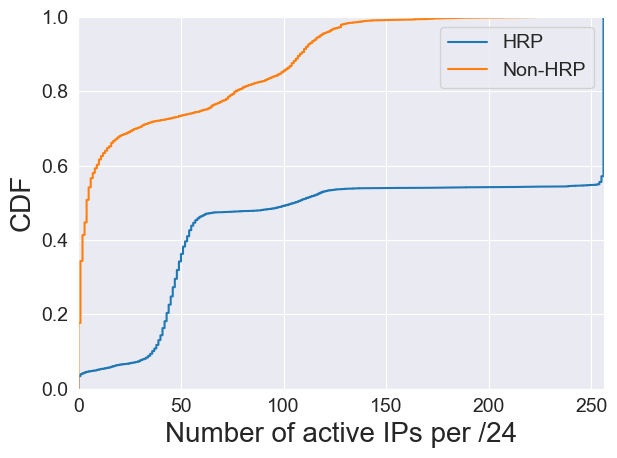

In [44]:
# plot distribution of active IPs for HRP and non-HRP

import numpy as np
# split data
hrp = census_v4[census_v4['is_hrp'] == True]['number_of_active_ips']
non_hrp = census_v4[census_v4['is_hrp'] == False]['number_of_active_ips']

hrp_sorted = np.sort(hrp)
non_hrp_sorted = np.sort(non_hrp)

hrp_cdf = np.arange(1, len(hrp_sorted) + 1) / len(hrp_sorted)
non_hrp_cdf = np.arange(1, len(non_hrp_sorted) + 1) / len(non_hrp_sorted)

plt.figure()

plt.plot(hrp_sorted, hrp_cdf, label="HRP")
plt.plot(non_hrp_sorted, non_hrp_cdf, label="Non-HRP")

plt.xlabel("Number of active IPs per /24")
plt.ylabel("CDF")
plt.xlim(0, 256)
plt.ylim(0, 1)

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


In [48]:
asn_table

,ASN,slash24s,active_ips,IP Utilization,HRP
67,13335,2866,657587,0.896266,0.989184
614,396982,4319,262845,0.237726,0.973837
828,54113,830,210443,0.990413,0.990361
155,16509,1589,130649,0.321175,0.244808
316,209242,268,59822,0.871939,0.977612
...,...,...,...,...,...
752,4764,1,0,0.000000,0.000000
450,26277,1,0,0.000000,0.000000
220,198734,1,0,0.000000,0.000000
756,48031,1,0,0.000000,0.000000


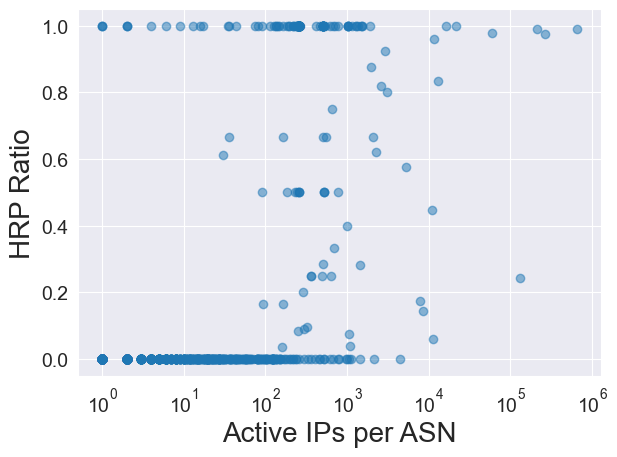

In [49]:
plt.figure()

plt.scatter(
    asn_table['active_ips'],
    asn_table['HRP'],
    alpha=0.5
)

plt.xscale('log')
plt.xlabel("Active IPs per ASN")
plt.ylabel("HRP Ratio")
plt.grid(True)
plt.tight_layout()
plt.show()

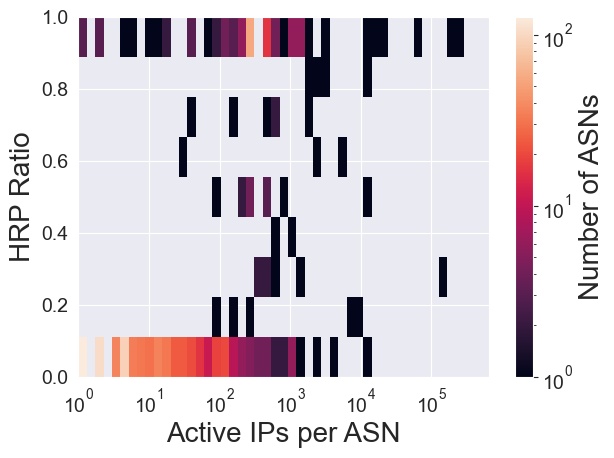

In [56]:
x = asn_table['active_ips']
y = asn_table['HRP']

plt.figure()

x_bins = np.logspace(
    np.log10(x[x > 0].min()),
    np.log10(x.max()),
    50
)

y_bins = np.linspace(0, 1, 10)

plt.hist2d(x, y, bins=[x_bins, y_bins], norm=LogNorm())

plt.xscale('log')
plt.xlabel("Active IPs per ASN")
plt.ylabel("HRP Ratio")

plt.colorbar(label="Number of ASNs")

plt.tight_layout()
plt.show()

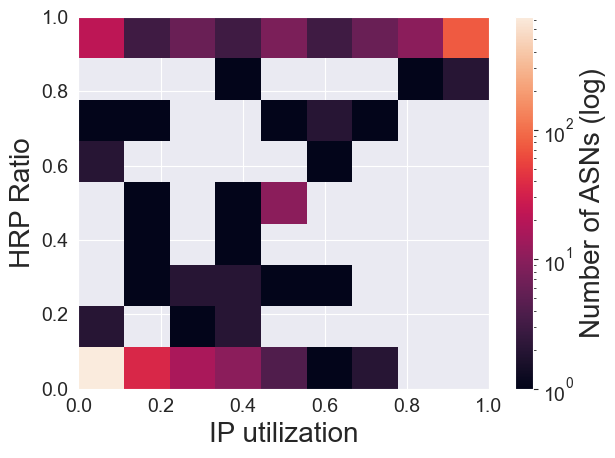

In [55]:
x = asn_table['IP Utilization']
y = asn_table['HRP']

plt.figure()

# x_bins = np.logspace(
#     np.log10(x[x > 0].min()),
#     np.log10(x.max()),
#     50
# )

x_bins = np.linspace(0, 1, 10)
y_bins = np.linspace(0, 1, 10)
from matplotlib.colors import LogNorm

plt.hist2d(x, y, bins=[x_bins, y_bins],
           norm=LogNorm())

# plt.xscale('log')
plt.xlabel("IP utilization")
plt.ylabel("HRP Ratio")

plt.colorbar(label="Number of ASNs (log)")

plt.tight_layout()
plt.show()

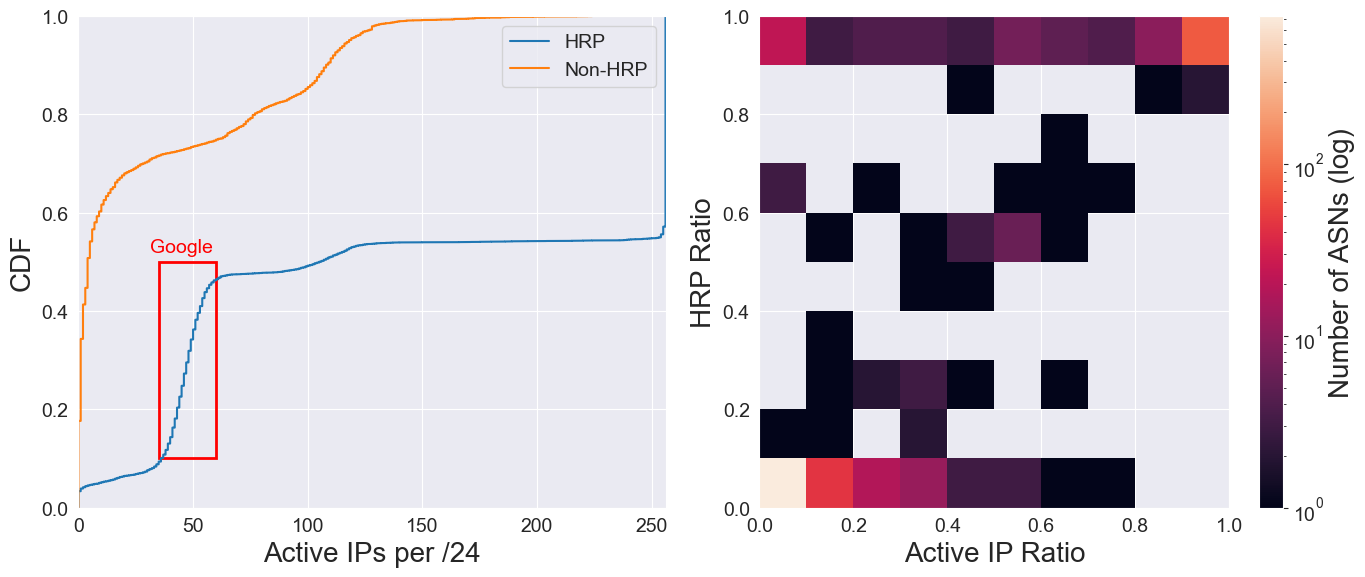

In [75]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# =========================
# LEFT PANEL — CDF (/24)
# =========================

hrp = census_v4[census_v4['is_hrp'] == True]['number_of_active_ips']
non_hrp = census_v4[census_v4['is_hrp'] == False]['number_of_active_ips']

hrp_sorted = np.sort(hrp)
non_hrp_sorted = np.sort(non_hrp)

hrp_cdf = np.arange(1, len(hrp_sorted) + 1) / len(hrp_sorted)
non_hrp_cdf = np.arange(1, len(non_hrp_sorted) + 1) / len(non_hrp_sorted)

ax1.step(hrp_sorted, hrp_cdf, where='post', label="HRP")
ax1.step(non_hrp_sorted, non_hrp_cdf, where='post', label="Non-HRP")

ax1.set_xlabel("Active IPs per /24")
ax1.set_ylabel("CDF")
ax1.set_xlim(0, 256)
ax1.set_ylim(0, 1)

from matplotlib.patches import Rectangle

# Define box: x=35–55, y=0.10–0.50
rect = Rectangle(
    (35, 0.10),   # bottom-left corner
    60-35,        # width
    0.50-0.10,    # height
    fill=False,
    edgecolor='red',
    linewidth=2
)

ax1.add_patch(rect)

# Add label
ax1.text(45, 0.52, "Google", color='red', ha='center')


ax1.grid(True)
ax1.legend()


# =========================
# RIGHT PANEL — ASN Heatmap
# =========================


x = asn_table['IP Utilization']
y = asn_table['HRP']

x_bins = np.linspace(0, 1, 11)
y_bins = np.linspace(0, 1, 11)

hist = ax2.hist2d(
    x,
    y,
    bins=[x_bins, y_bins],
    norm=LogNorm()
)

ax2.set_xlabel("Active IP Ratio")
ax2.set_ylabel("HRP Ratio")

cbar = fig.colorbar(hist[3], ax=ax2)
cbar.set_label("Number of ASNs (log)")

plt.savefig("ip_utilization.pdf", bbox_inches='tight', pad_inches=0)

plt.tight_layout()
plt.show()


In [67]:
# which AS originates 35-50 active IPs for HRP prefixes

hrp = census_v4[census_v4['is_hrp']]
hrp_filtered = hrp[(hrp['number_of_active_ips'] > 35) & (hrp['number_of_active_ips'] < 65)]
hrp_filtered

,prefix,AB_ICMPv4,AB_TCPv4,AB_DNSv4,GCD_ICMPv4,GCD_TCPv4,partial,backing_prefix,ASN,locations,is_hrp,number_of_active_ips,ip_utilization
3144,107.178.240.0/24,18,18,0,62,0,False,107.178.224.0/19,396982,"[{'city': 'Ashburn', 'country_code': 'US', 'id...",True,51,0.199219
3145,107.178.241.0/24,18,19,0,63,0,False,107.178.224.0/19,396982,"[{'city': 'Santiago', 'country_code': 'CL', 'i...",True,50,0.195312
3146,107.178.242.0/24,18,0,0,64,0,False,107.178.224.0/19,396982,"[{'city': None, 'country_code': None, 'id': 'N...",True,58,0.226562
3147,107.178.243.0/24,18,18,0,62,0,False,107.178.224.0/19,396982,"[{'city': None, 'country_code': None, 'id': 'N...",True,48,0.187500
3148,107.178.244.0/24,18,18,0,63,0,False,107.178.224.0/19,396982,"[{'city': 'Doha', 'country_code': 'QA', 'id': ...",True,43,0.167969
...,...,...,...,...,...,...,...,...,...,...,...,...,...
34544,85.128.254.0/24,6,0,0,7,0,False,85.128.192.0/18,15967,"[{'city': 'Los Angeles', 'country_code': 'US',...",True,41,0.160156
34545,85.128.255.0/24,6,0,0,7,0,False,85.128.192.0/18,15967,"[{'city': 'Warsaw', 'country_code': 'PL', 'id'...",True,46,0.179688
35206,91.206.127.0/24,2,0,0,2,0,False,91.206.127.0/24,201706,"[{'city': 'Frankfurt-am-Main', 'country_code':...",True,44,0.171875
35683,94.188.230.0/24,2,2,0,2,1,False,94.188.230.0/24,48851,"[{'city': 'Frankfurt-am-Main', 'country_code':...",True,47,0.183594


In [68]:
hrp_filtered.groupby('ASN')['prefix'].nunique().sort_values(ascending=False)

ASN
396982    3484
15967      162
48851        7
25773        5
394089       2
12008        1
19527        1
198949       1
201706       1
209242       1
40509        1
Name: prefix, dtype: int64